Loading chains...
Computing posterior...
Plotting...


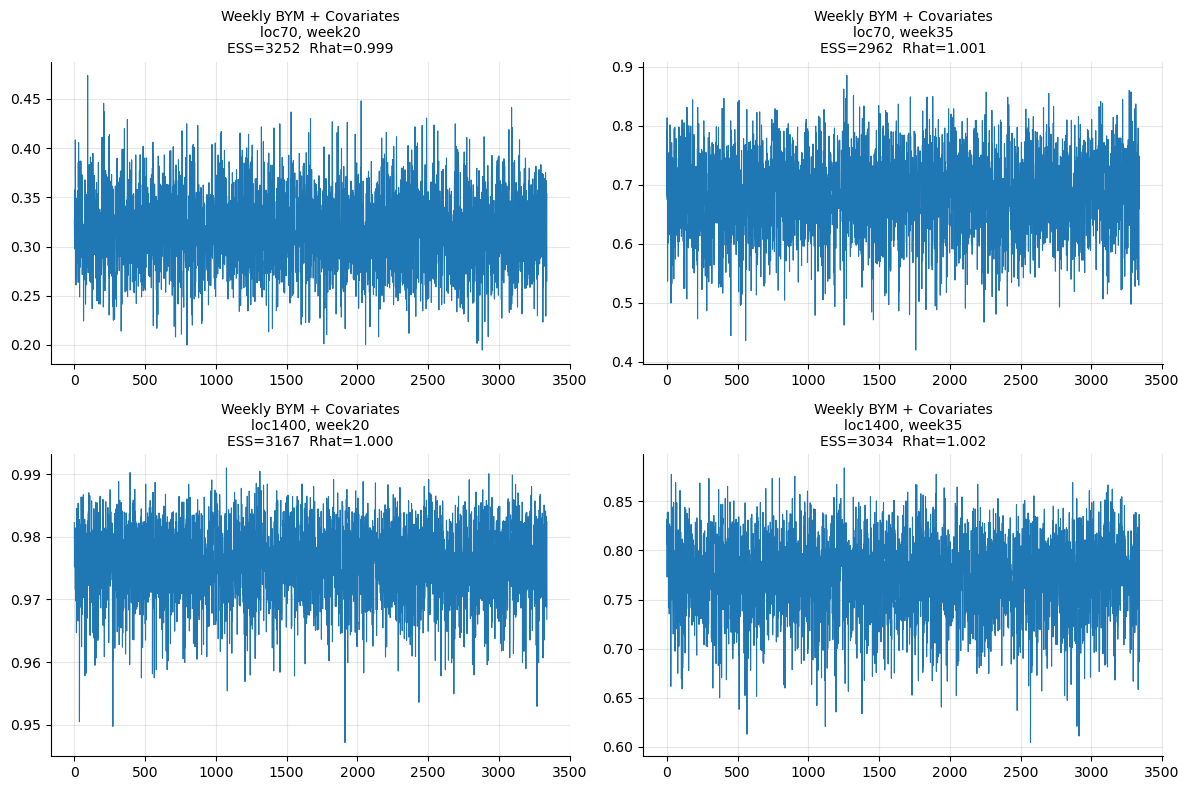

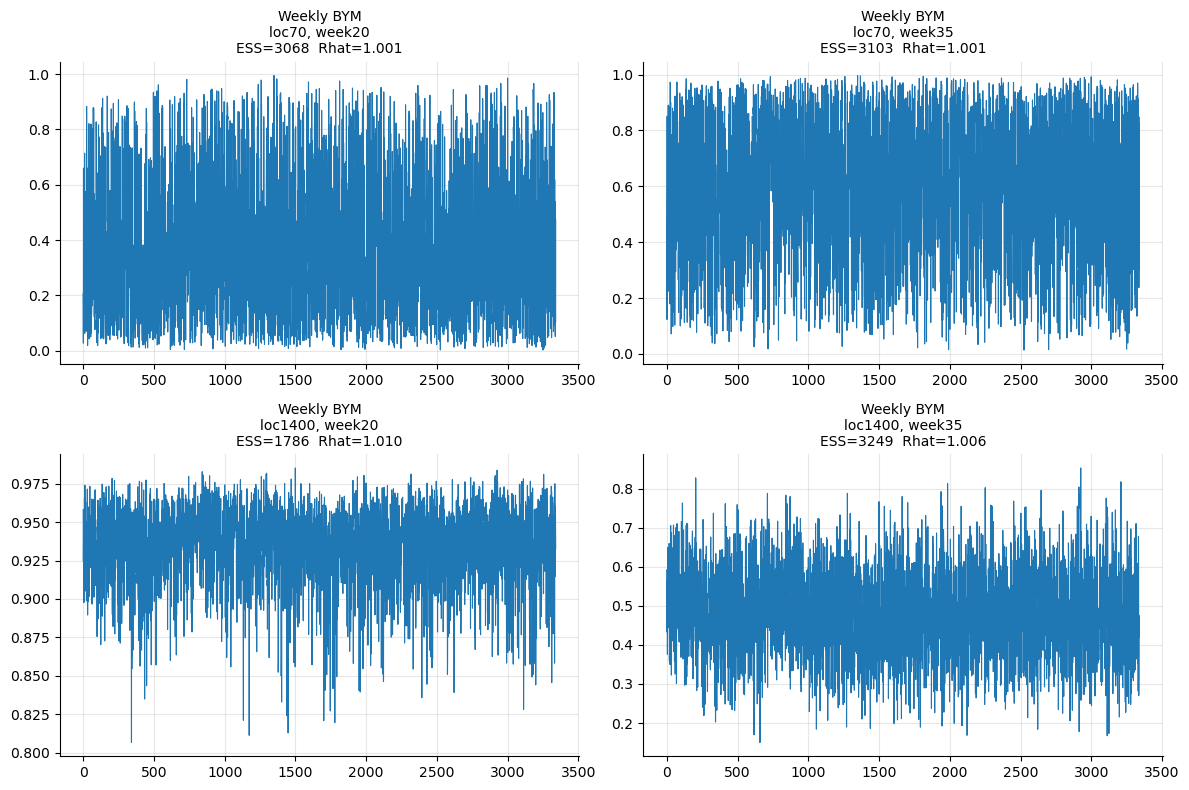

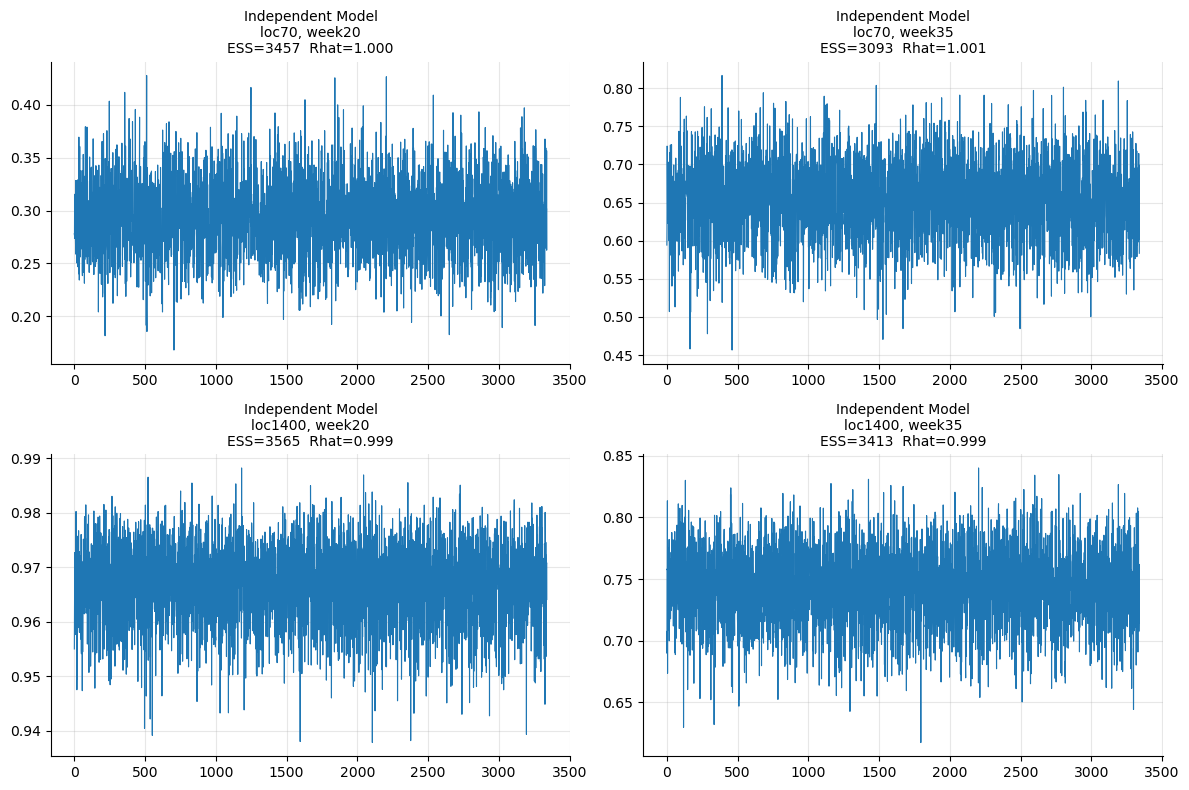

Done.


In [ ]:
# ================================================================
# TRACEPLOT (FINAL VERSION)
# Independent / Weekly BYM / Weekly BYM + Covariates
# pooled chains + ESS + Rhat
# plotnine (ggplot style)
# ================================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import arviz as az
import pickle
import pyreadr

from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

from plotnine import *

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")

period = 52
thin2 = 15

locations = [70, 1400]
weeks = [20, 35]
year = 20

times = [(year*52 + w - 1) for w in weeks]
chains = list(range(10))

# ================================================================
# LOAD DATA
# ================================================================

no_nbs = np.array([
57,170,236,269,343,685,946,947,989,
1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

def load_data():
    snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
    snow = list(snow.values())[0].reset_index(drop=True)
    snow = snow.drop(index=no_nbs).reset_index(drop=True)

    coords_full = snow.iloc[:, :2].to_numpy()
    y_full = snow.iloc[:, 2:].to_numpy()

    return coords_full, y_full

coords_full, y_full = load_data()

# adjacency + keep
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(W_full, 0)

n_comp, labels = connected_components(csr_matrix(W_full), directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape

# ================================================================
# COVARIATES
# ================================================================

lat_raw = coords[:,1]
lat = (lat_raw - lat_raw.mean()) / lat_raw.std()

elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = elev_raw[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)

temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# LOAD CHAINS
# ================================================================

def load_bym(prefix, use_cov=False):

    eta_list, tau_list = [], []

    for c in chains:

        if use_cov:
            fname = f"{prefix}_chain{c}+cov.pkl"
        else:
            fname = f"{prefix}_chain{c}.pkl"

        with open(BASE_DIR / fname, "rb") as f:
            d = pickle.load(f)

        eta_list.append(d["eta"][:, ::thin2])
        tau_list.append(d["tau"][:, ::thin2])

    return eta_list, tau_list


def load_ind(prefix):

    eta_list = []

    for c in chains:
        d = np.load(BASE_DIR / f"{prefix}_chain{c}.npz")
        key = d.files[0]
        eta_list.append(d[key][:, ::thin2])

    return eta_list

# ================================================================
# DIAGNOSTICS
# ================================================================

def compute_rhat(chains):
    return float(az.rhat(np.array(chains)))

def compute_ess(samples):
    return float(az.ess(np.array(samples)))

# ================================================================
# POSTERIOR RECONSTRUCTION
# ================================================================

def compute_p_bym(eta_list, tau_list):

    K_total = 8
    S = (eta_list[0].shape[0] - 3)//K_total

    results = {}

    for s in locations:
        for t in times:

            w = t % 52
            t_scaled = t_scaled_full[t]

            cov4 = np.array([
                1,
                np.cos(2*np.pi*(t+1)/period),
                np.sin(2*np.pi*(t+1)/period),
                t_scaled
            ])

            chains_out = []

            for c in range(len(eta_list)):

                eta = eta_list[c]
                tau = tau_list[c]

                phi = np.zeros(eta.shape[1])

                for k in range(8):
                    beta = eta[k*S+s,:]*tau[k*52+w,:]
                    phi += beta * cov4[k//2]

                gamma = eta[8*S:8*S+3,:]

                phi += gamma[0]*t_scaled*lat[s]
                phi += gamma[1]*t_scaled*elev[s]
                phi += gamma[2]*t_scaled*temp_scaled[s,t]

                p = 1/(1+np.exp(-phi))

                if y[s,t]==0:
                    p_final = p
                else:
                    p_final = 1-p

                chains_out.append(p_final)

            results[(s,t)] = chains_out

    return results


def compute_p_ind(eta_list):

    K = 4
    S = eta_list[0].shape[0] // K

    results = {}

    for s in locations:
        for t in times:

            t_scaled = t_scaled_full[t]

            cov4 = np.array([
                1,
                np.cos(2*np.pi*(t+1)/period),
                np.sin(2*np.pi*(t+1)/period),
                t_scaled
            ])

            chains_out = []

            for c in range(len(eta_list)):

                eta = eta_list[c]
                phi = np.zeros(eta.shape[1])

                for k in range(K):
                    beta = eta[k*S+s,:]
                    phi += beta * cov4[k]

                p = 1/(1+np.exp(-phi))

                if y[s,t]==0:
                    p_final = p
                else:
                    p_final = 1-p

                chains_out.append(p_final)

            results[(s,t)] = chains_out

    return results

# ================================================================
# BUILD DATAFRAME
# ================================================================

def build_trace_df_single(results, model_label):

    rows = []

    for (s,t), chains_list in results.items():

        Rhat = compute_rhat(chains_list)
        pooled = np.concatenate(chains_list)
        ess = compute_ess(pooled)

        for i, val in enumerate(pooled):
            rows.append({
                "iter": i,
                "value": val,
                "location": f"loc{s}",
                "week": f"week{t%52+1}",
                "ESS": ess,
                "Rhat": Rhat,
                "model": model_label
            })

    return pd.DataFrame(rows)

# ================================================================
# PLOT SINGLE MODEL
# ================================================================

import matplotlib.pyplot as plt

# ================================================================
# FINAL PLOT FUNCTION（核心）
# ================================================================

def plot_model_subplots(results, model_name):

    fig, axs = plt.subplots(len(locations), len(times), figsize=(12,8))
    axs = np.atleast_2d(axs)

    for i, s in enumerate(locations):
        for j, t in enumerate(times):

            p_chains = results[(s,t)]

            # ---------- diagnostics ----------
            Rhat = float(az.rhat(np.array(p_chains)))
            pooled = np.concatenate(p_chains)
            ess = float(az.ess(pooled))

            # ---------- plot ----------
            ax = axs[i,j]
            ax.plot(pooled, lw=0.8)

            # ---------- title ----------
            ax.set_title(
                f"{model_name}\nloc{s}, week{t%52+1}\nESS={ess:.0f}  Rhat={Rhat:.3f}",
                fontsize=10
            )

            # ---------- clean style（接近ggplot） ----------
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ================================================================
# RUN
# ================================================================

print("Loading chains...")

eta10_cov, tau10_cov = load_bym("bym10", True)
eta10, tau10 = load_bym("bym10", False)
eta_ind10 = load_ind("ind10")

print("Computing posterior...")

res_cov = compute_p_bym(eta10_cov, tau10_cov)
res_bym = compute_p_bym(eta10, tau10)
res_ind = compute_p_ind(eta_ind10)

print("Plotting...")

# =========================
# Weekly BYM + Covariates
# =========================
plot_model_subplots(res_cov, "Weekly BYM + Covariates")

# =========================
# Weekly BYM
# =========================
plot_model_subplots(res_bym, "Weekly BYM")

# =========================
# Independent Model
# =========================
plot_model_subplots(res_ind, "Independent Model")
print("Done.")

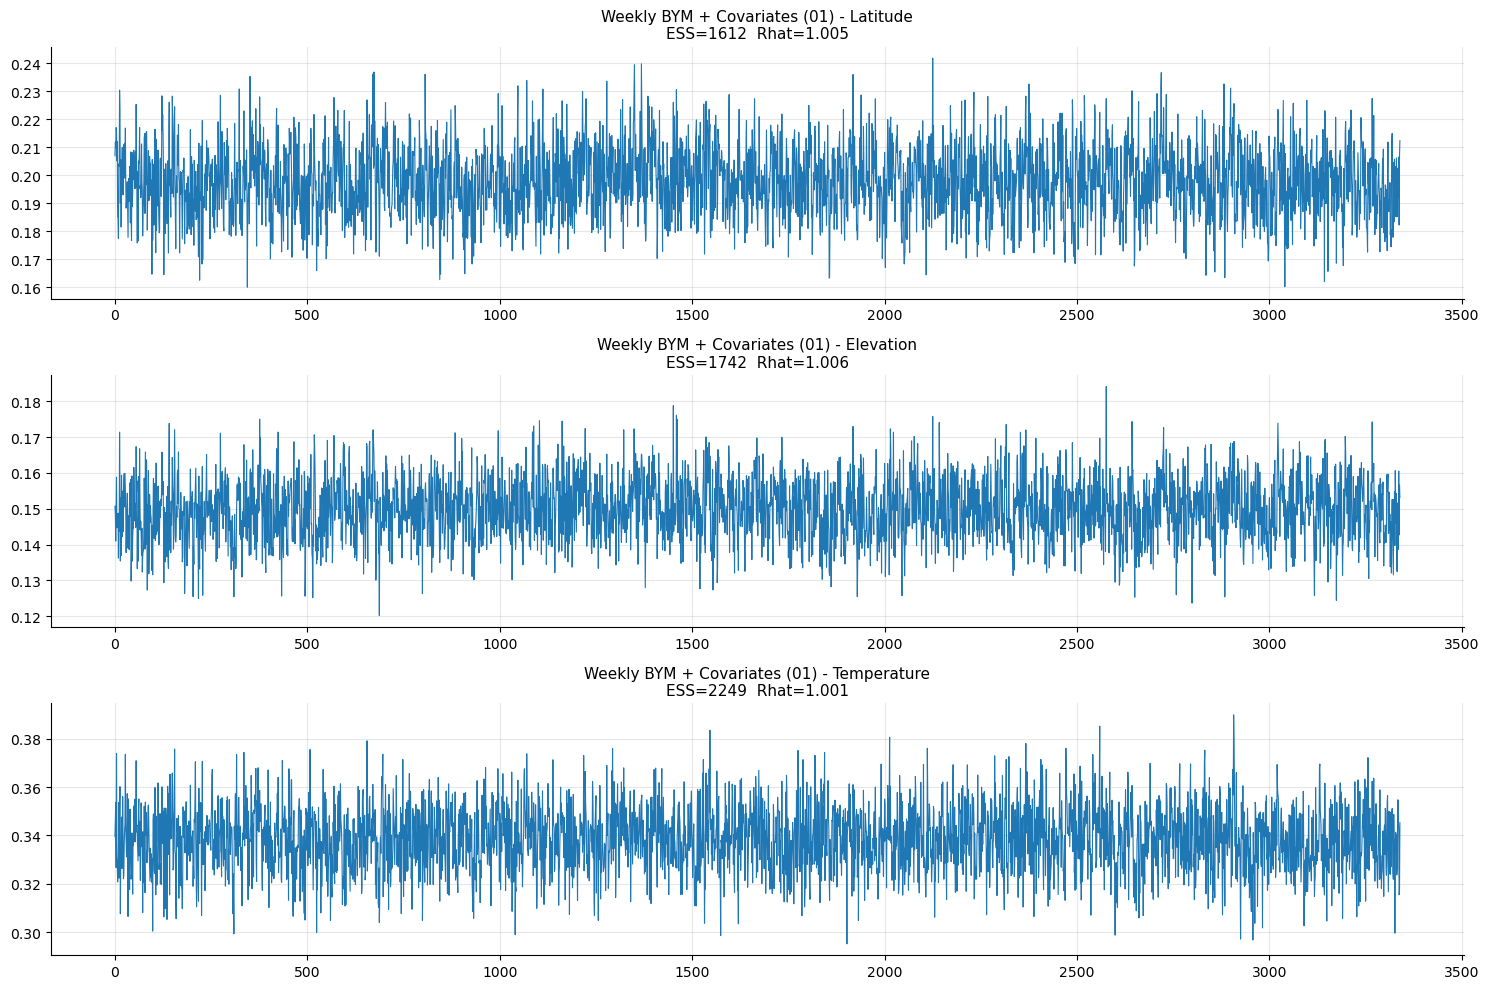

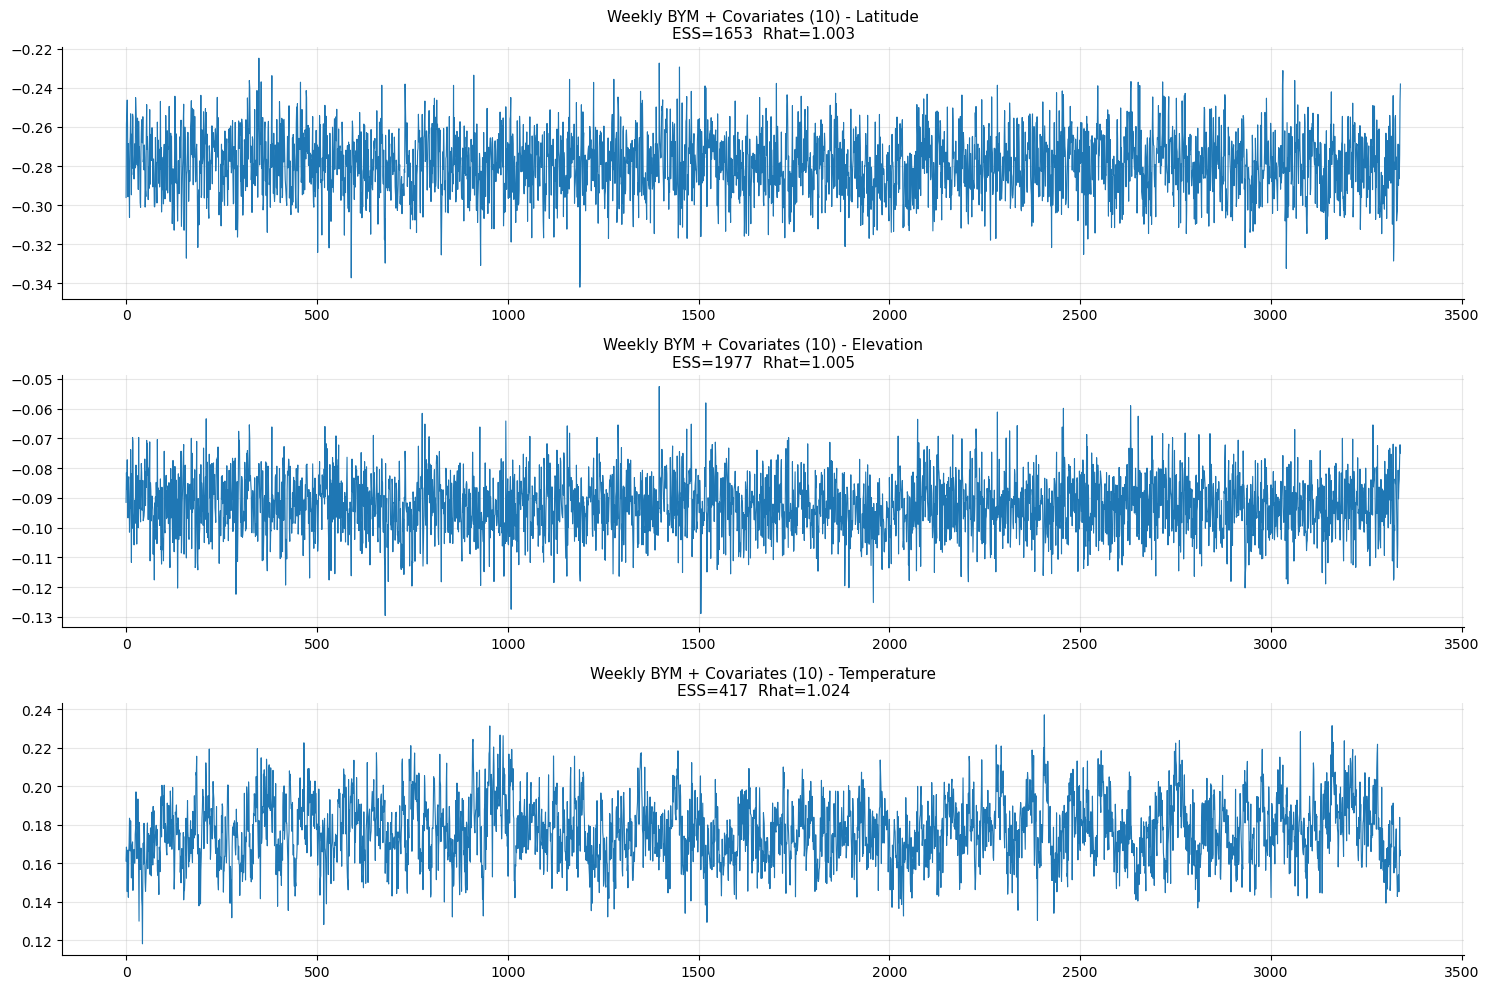

In [3]:
def plot_gamma_subplots(eta_list, model_name):

    K_total = 8
    S = (eta_list[0].shape[0] - 3) // K_total

    cov_names = ["Latitude", "Elevation", "Temperature"]

    fig, axs = plt.subplots(3, 1, figsize=(15,10))

    for k in range(3):

        # ---------- collect chains ----------
        chains = []

        for c in range(len(eta_list)):
            gamma = eta_list[c][8*S + k, :]
            chains.append(gamma)

        # ---------- diagnostics ----------
        Rhat = float(az.rhat(np.array(chains)))
        pooled = np.concatenate(chains)
        ess = float(az.ess(pooled))

        # ---------- plot ----------
        ax = axs[k]
        ax.plot(pooled, lw=0.8)

        # ---------- title ----------
        ax.set_title(
            f"{model_name} - {cov_names[k]}\nESS={ess:.0f}  Rhat={Rhat:.3f}",
            fontsize=11
        )

        # ---------- ggplot-like style ----------
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
eta01_cov, tau01_cov = load_bym("bym01", True)
eta10_cov, tau10_cov = load_bym("bym10", True)

# =========================
# BYM01 + cov
# =========================
plot_gamma_subplots(eta01_cov, "Weekly BYM + Covariates (01)")

# =========================
# BYM10 + cov
# =========================
plot_gamma_subplots(eta10_cov, "Weekly BYM + Covariates (10)")

In [1]:
# ================================================================
# FULL VECTORIZED VERSION (NO PARALLEL)
# RUN IN VSCode / JUPYTER
#
# ✔ Fast (vectorized over locations S)
# ✔ Stable (no multiprocessing issues)
# ✔ Models:
#     - Independent Model
#     - Weekly BYM
#     - Weekly BYM + Covariates
#
# OUTPUT: ess_rhat_all_models.csv
# ================================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import arviz as az
import pickle
import pyreadr
from pathlib import Path
from tqdm import tqdm

from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")

period = 52
thin2 = 15
chains = list(range(10))

# ================================================================
# LOAD DATA
# ================================================================

no_nbs = np.array([
57,170,236,269,343,685,946,947,989,
1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

def load_data():
    snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
    snow = list(snow.values())[0].reset_index(drop=True)
    snow = snow.drop(index=no_nbs).reset_index(drop=True)

    coords_full = snow.iloc[:, :2].to_numpy()
    y_full = snow.iloc[:, 2:].to_numpy()

    return coords_full, y_full

coords_full, y_full = load_data()

# ================================================================
# GRAPH
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(W_full, 0)

n_comp, labels = connected_components(csr_matrix(W_full), directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape

# ================================================================
# COVARIATES
# ================================================================

lat = (coords[:,1] - coords[:,1].mean()) / coords[:,1].std()

elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = elev_raw[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)

temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# LOAD CHAINS
# ================================================================

def load_bym(prefix, use_cov=False):
    eta_list, tau_list = [], []
    for c in chains:
        fname = f"{prefix}_chain{c}+cov.pkl" if use_cov else f"{prefix}_chain{c}.pkl"
        with open(BASE_DIR / fname, "rb") as f:
            d = pickle.load(f)
        eta_list.append(d["eta"][:, ::thin2])
        tau_list.append(d["tau"][:, ::thin2])
    return eta_list, tau_list


def load_ind(prefix):
    eta_list = []
    for c in chains:
        d = np.load(BASE_DIR / f"{prefix}_chain{c}.npz")
        key = d.files[0]
        eta_list.append(d[key][:, ::thin2])
    return eta_list

# ================================================================
# VECTORIZED BYM
# ================================================================

def diagnostics_bym_vectorized(eta_list, tau_list, model_name):

    eta_dim = eta_list[0].shape[0]

    if eta_dim % 8 == 0:
        has_cov = False
        S_local = eta_dim // 8
    else:
        has_cov = True
        S_local = (eta_dim - 3) // 8

    K = 8
    C = len(eta_list)
    draws = eta_list[0].shape[1]

    rows = []

    # precompute
    t_idx = np.arange(TT)
    cov4_all = np.vstack([
        np.ones(TT),
        np.cos(2*np.pi*(t_idx+1)/period),
        np.sin(2*np.pi*(t_idx+1)/period),
        t_scaled_full
    ]).T

    if has_cov:
        t_lat  = np.outer(lat, t_scaled_full)
        t_elev = np.outer(elev, t_scaled_full)
        t_temp = temp_scaled * t_scaled_full

    for t in tqdm(range(1, TT), desc=model_name):

        w = t % 52
        cov4 = cov4_all[t]

        p_chains = []

        for c in range(C):

            eta = eta_list[c]
            tau = tau_list[c]

            phi = np.zeros((S_local, draws))

            for k in range(K):
                eta_block = eta[k*S_local:(k+1)*S_local, :]
                tau_vec   = tau[k*52 + w, :]
                phi += eta_block * tau_vec * cov4[k//2]

            if has_cov:
                gamma = eta[8*S_local:8*S_local+3, :]
                phi += gamma[0] * t_lat[:, t][:, None]
                phi += gamma[1] * t_elev[:, t][:, None]
                phi += gamma[2] * t_temp[:, t][:, None]

            p = 1/(1+np.exp(-phi))

            mask = (y[:, t] == 1)
            p[mask, :] = 1 - p[mask, :]

            p_chains.append(p)

        # diagnostics per location
        for s in range(S_local):

            chains_s = [p_chains[c][s, :] for c in range(C)]

            Rhat = float(az.rhat(np.array(chains_s)))
            ess  = float(az.ess(np.concatenate(chains_s)))

            rows.append({
                "location": s,
                "time": t,
                "ESS": ess,
                "Rhat": Rhat,
                "model": model_name
            })

    return pd.DataFrame(rows)

# ================================================================
# VECTORIZED IND
# ================================================================

def diagnostics_ind_vectorized(eta_list, model_name):

    K = 4
    S_local = eta_list[0].shape[0] // K
    C = len(eta_list)
    draws = eta_list[0].shape[1]

    rows = []

    t_idx = np.arange(TT)
    cov4_all = np.vstack([
        np.ones(TT),
        np.cos(2*np.pi*(t_idx+1)/period),
        np.sin(2*np.pi*(t_idx+1)/period),
        t_scaled_full
    ]).T

    for t in tqdm(range(1, TT), desc=model_name):

        cov4 = cov4_all[t]
        p_chains = []

        for c in range(C):

            eta = eta_list[c]
            phi = np.zeros((S_local, draws))

            for k in range(K):
                phi += eta[k*S_local:(k+1)*S_local, :] * cov4[k]

            p = 1/(1+np.exp(-phi))

            mask = (y[:, t] == 1)
            p[mask, :] = 1 - p[mask, :]

            p_chains.append(p)

        for s in range(S_local):

            chains_s = [p_chains[c][s, :] for c in range(C)]

            Rhat = float(az.rhat(np.array(chains_s)))
            ess  = float(az.ess(np.concatenate(chains_s)))

            rows.append({
                "location": s,
                "time": t,
                "ESS": ess,
                "Rhat": Rhat,
                "model": model_name
            })

    return pd.DataFrame(rows)

# ================================================================
# RUN
# ================================================================

print("Loading chains...")

eta_cov, tau_cov = load_bym("bym10", True)
eta_bym, tau_bym = load_bym("bym10", False)
eta_ind = load_ind("ind10")

print("Running diagnostics...")

df_cov = diagnostics_bym_vectorized(eta_cov, tau_cov, "Weekly BYM + Covariates")
df_bym = diagnostics_bym_vectorized(eta_bym, tau_bym, "Weekly BYM")
df_ind = diagnostics_ind_vectorized(eta_ind, "Independent Model")

df_all = pd.concat([df_cov, df_bym, df_ind], ignore_index=True)

out = BASE_DIR / "ess_rhat_all_models.csv"
df_all.to_csv(out, index=False)

print("Done.")
print("Saved to:", out)
print(df_all.head())

Loading chains...
Running diagnostics...


Independent Model: 100%|██████████| 2703/2703 [2:52:42<00:00,  3.83s/it]  


Done.
Saved to: D:\77\Research\temp\snow\ess_rhat_all_models.csv
   location  time          ESS      Rhat                    model
0         0     1  3004.810404  1.002777  Weekly BYM + Covariates
1         1     1  3244.273622  0.999505  Weekly BYM + Covariates
2         2     1  3219.868196  1.000812  Weekly BYM + Covariates
3         3     1  2869.695246  1.003047  Weekly BYM + Covariates
4         4     1  3256.728816  1.002053  Weekly BYM + Covariates


In [6]:
models = ["Independent Model", "Weekly BYM", "Weekly BYM + Covariates"]

for m in models:
    df = df_all[df_all["model"] == m]

    rhat_pct = (df["Rhat"] < 1.05).mean() * 100
    ess_pct  = (df["ESS"] > 400).mean() * 100

    print(f"\nModel: {m}")
    print(f"Rhat < 1.05: {rhat_pct:.2f}%")
    print(f"ESS  > 400 : {ess_pct:.2f}%")


Model: Independent Model
Rhat < 1.05: 100.00%
ESS  > 400 : 99.28%

Model: Weekly BYM
Rhat < 1.05: 98.70%
ESS  > 400 : 96.67%

Model: Weekly BYM + Covariates
Rhat < 1.05: 99.04%
ESS  > 400 : 97.03%
